In [1]:
import os
import sys
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '../..')) # Adjust as needed
if project_root not in sys.path:
    sys.path.append(project_root) # add notebook to sys.path

# Comparing performance of matrix multiplication for different vectorization strategies

In [2]:
import torch
from torch import nn

from utils.timer import Timer

In [3]:
device = torch.device('cpu')
#device = torch.device('mps')

In [4]:
N = 256
BS = 64
flops = 2 * N * N * N / 1e9

In [5]:
A = torch.zeros(N, N).to(device)
B = torch.randn(N, N).to(device)
C = torch.randn(N, N).to(device)

In [6]:
timer = Timer()

In [7]:
timer.start()
for j in range(N):
    A[:, j] = torch.mv(B, C[:, j])
timer.stop()

0.006011962890625

In [8]:
timer.start()
A = torch.mm(B, C)
timer.stop()

0.0002410411834716797

In [9]:
gigaflops = [flops / i for i in timer.times]
print(f'performance in Gigaflops:'
      f'column {gigaflops[0]:.3f}, full {gigaflops[1]:.3f}')

performance in Gigaflops:column 5.581, full 139.206


In [10]:
timer.start()
for j in range(0, N, BS):
    A[:, j:j+BS] = torch.mm(B, C[:, j:j+BS])
timer.stop()
print(f'performance in Gigaflops: block {flops / timer.times[2]:.3f}')

performance in Gigaflops: block 17.772


# Commparing performance of SGD for different batch sizes

In [11]:
from utils.data import get_nasa_data
from utils.train import train_optimization, train_optimization_concise

In [12]:
def sgd(params, states, hyperparams):
    for p in params:
        p.data.sub_(hyperparams['lr'] * p.grad)
        p.grad.data.zero_()

def train_sgd(lr, batch_size, num_epochs=2):
    data_iter, feature_dim = get_nasa_data(batch_size)
    return train_optimization(
        sgd, None, {'lr': lr}, data_iter, feature_dim, num_epochs)

loss: 0.244, 0.006 sec/epoch


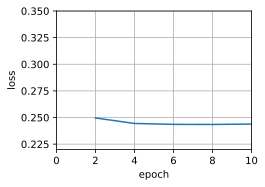

In [13]:
gd_res = train_sgd(1, 1500, 10)

loss: 0.250, 0.133 sec/epoch


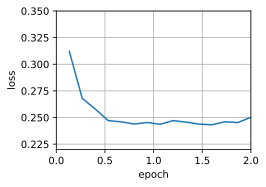

In [14]:
sgd_res = train_sgd(0.005, 1)

loss: 0.243, 0.011 sec/epoch


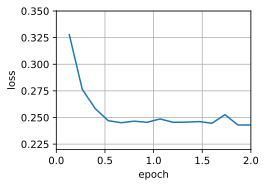

In [15]:
mini1_res = train_sgd(.4, 100)

loss: 0.243, 0.024 sec/epoch


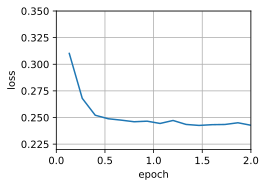

In [16]:
mini2_res = train_sgd(.05, 10)

In [17]:
from matplotlib_inline import backend_inline
import matplotlib.pyplot as plt
from IPython import display

def use_svg_display():
    backend_inline.set_matplotlib_formats('svg')

def set_figsize(figsize=(3.5, 2.5)):
    """Set the figure size for matplotlib.

    Defined in :numref:`sec_calculus`"""
    use_svg_display()
    plt.rcParams['figure.figsize'] = figsize

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """Set the axes for matplotlib.

    Defined in :numref:`sec_calculus`"""
    axes.set_xlabel(xlabel), axes.set_ylabel(ylabel)
    axes.set_xscale(xscale), axes.set_yscale(yscale)
    axes.set_xlim(xlim),     axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

def plot(X, Y=None, xlabel=None, ylabel=None, legend=[], xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """Plot data points.

    Defined in :numref:`sec_calculus`"""

    def has_one_axis(X):  # True if X (tensor or list) has 1 axis
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X): X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)

    set_figsize(figsize)
    if axes is None:
        axes = plt.gca()
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        axes.plot(x,y,fmt) if len(x) else axes.plot(y,fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

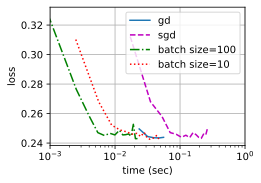

In [18]:
set_figsize([6, 3])
plot(*list(map(list, zip(gd_res, sgd_res, mini1_res, mini2_res))),
         'time (sec)', 'loss', xlim=[1e-3, 1],
         legend=['gd', 'sgd', 'batch size=100', 'batch size=10'])
plt.gca().set_xscale('log')

loss: 0.244, 0.026 sec/epoch


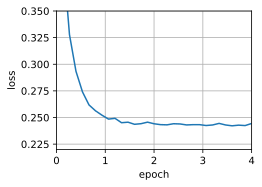

In [19]:
data_iter, _ = get_nasa_data(batch_size=10)
trainer = torch.optim.SGD
train_optimization_concise(trainer, {'lr': 0.01}, data_iter)